# Tutorial 5 - three observed targets: success, mild and severe degeneracy

This notebook runs the end-to-end analysis for the three real targets discussed in the paper.
They were selected because they represent the three regimes of the quality label:

| label | target | why |
|---|---|---|
| `Success` | G13619209590707 | large RV span, high SNR, well constrained |
| `Mild Degeneracy` | G16857550743084 | the DIB and the stellar line are closer in width |
| `Severe Degeneracy` | G16954716324740 | small RV span, the parameters are degenerate (large $\tau$) |

Each target is a LAMOST medium-resolution (MRS) single-lined binary: several epochs of the red
channel are normalised to the continuum, resampled on a common grid and fitted simultaneously.
The autocorrelation time $\tau$ of the chains measures how many steps the sampler needs for an
independent sample; large $\tau$ means a degenerate posterior, which is exactly what the quality
label flags.

The analysis-ready spectra shipped in `data/real/<uid>/preprocessed.fits` are the same files used for
the paper, and the corresponding raw LAMOST DR12 files are included in
`data/real/<uid>/raw/` so that the preprocessing can be repeated from scratch
(`scripts/download_lamost_spectra.py` fetches them for other targets).

In [1]:
%matplotlib inline
import json, sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:                                     # installed with `pip install -e .`
    import mcmc_rvsd
except ImportError:                      # or run straight from a clone
    sys.path.insert(0, str(Path.cwd().parent / 'src'))
    import mcmc_rvsd
from mcmc_rvsd import SpectralModel, StellarLine, DIB, run_mcmc, plotting
from mcmc_rvsd.io import load_result, load_mock
from mcmc_rvsd.preprocess import read_preprocessed

ROOT = Path.cwd().parent if Path.cwd().name == 'examples' else Path.cwd()
FIG = ROOT / 'docs' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
RERUN = False             # set to True to redo the MCMC yourself (minutes)
print('mcmc_rvsd', mcmc_rvsd.__version__, '|',
      'running from a repository clone' if (ROOT / 'data').is_dir() else 'running from an installed package')

mcmc_rvsd 0.1.0 | running from a repository clone


## 1. The three targets

In [2]:
TARGETS = {'G13619209590707': 'Success',
           'G16857550743084': 'Mild Degeneracy',
           'G16954716324740': 'Severe Degeneracy'}
for uid, expectation in TARGETS.items():
    d = read_preprocessed(ROOT / 'data/real' / uid / 'preprocessed.fits')
    print(f'{uid} ({expectation:>18}): {len(d["rvs"])} epochs | '
          f'RV span {np.ptp(d["rvs"]):5.1f} km/s | median SNR {np.median(d["snrs"]):5.1f}')

G13619209590707 (           Success): 2 epochs | RV span  29.0 km/s | median SNR 450.8
G16857550743084 (   Mild Degeneracy): 6 epochs | RV span   5.0 km/s | median SNR 161.8
G16954716324740 ( Severe Degeneracy): 13 epochs | RV span  15.5 km/s | median SNR 256.2



## 2. From the raw spectrum to the analysis-ready file

The spectra of the three targets are public LAMOST DR12 medium-resolution data. The raw files
shipped in `data/real/<uid>/raw/` are the ones downloaded from the DR12 server (one per target,
~0.5 MB); `mcmc_rvsd.preprocess` performs exactly the same steps that produced the
`preprocessed.fits` files:

1. read the red channel (`COADD_R`) of the LAMOST FITS, mask the flagged pixels;
2. convert vacuum to air wavelengths and cut the window around the DIB (6604-6664 A);
3. resample onto the common 0.12 A grid;
4. normalise the continuum iteratively (`specnorm`), interpolating over spikes and bad pixels.

The cell below runs the preprocessing on one raw file and plots the normalised result.


normalised spectrum: 501 pixels | RV = 3.42 km/s | SNR = 211.2


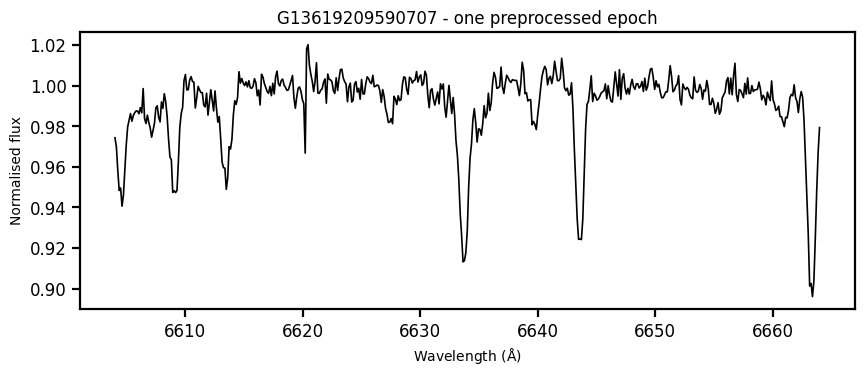

In [3]:
from mcmc_rvsd import preprocess

uid = 'G13619209590707'
raw = ROOT / 'data/real' / uid / 'raw' / f'{uid}_934314249.fits'
single = preprocess.preprocess_spectrum(str(raw))
print(f'normalised spectrum: {single["flux_norm"].shape[0]} pixels | '
      f'RV = {single["rv"]:.2f} km/s | SNR = {single["snr"]:.1f}')

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(single['wave'], single['flux_norm'], lw=1.2, color='k')
ax.set_xlabel(r'Wavelength ($\rm\AA$)'); ax.set_ylabel('Normalised flux')
ax.set_title(f'{uid} - one preprocessed epoch')
plotting.style_axes(ax)
fig.savefig(FIG / 'nb05_preprocess.png', dpi=200, bbox_inches='tight')
plt.show()


## 3. Fit (or load) each target and look at the posterior

In [4]:
model = SpectralModel(stellar_lines=[StellarLine('FeI', 6613.8225)],
                      dib=DIB(profile='gaussian'))
p0 = np.array([6613.6, 0.010, 0.5, 6613.7303, 0.0455, 0.5367])

runs = {}
for uid, expectation in TARGETS.items():
    d = read_preprocessed(ROOT / 'data/real' / uid / 'preprocessed.fits')
    if RERUN:
        res = run_mcmc(model, d['wave'], d['flux'], d['flux_err'], d['rvs'], d['rv_errs'],
                       p0=p0, snrs=d['snrs'], seed=42)
        res.save(ROOT / 'data/real' / uid / 'mcmc_result.npz', thin=10)
    else:
        res = load_result(ROOT / 'data/real' / uid / 'mcmc_result.npz')
    runs[uid] = (d, res)
    print(f'--- {uid} (expected: {expectation})')
    q = res.pfit[3:]
    L = getattr(res, 'production', 5000) or 5000
    print(f'    label = {res.label} | L/tau_DIB = {L / res.tau[-3:].min():.0f}-{L / res.tau[-3:].max():.0f} samples | '
          f'lambda_DIB = {q[0]:.3f} A, A_DIB = {q[1]:.4f}, sigma_DIB = {q[2]:.3f} A')

--- G13619209590707 (expected: Success)
    label = Success | L/tau_DIB = 84-74 samples | lambda_DIB = 6613.394 A, A_DIB = 0.0236, sigma_DIB = 0.412 A
--- G16857550743084 (expected: Mild Degeneracy)
    label = Mild Degeneracy | L/tau_DIB = 32-31 samples | lambda_DIB = 6613.682 A, A_DIB = 0.0509, sigma_DIB = 0.384 A
--- G16954716324740 (expected: Severe Degeneracy)
    label = Severe Degeneracy | L/tau_DIB = 37-21 samples | lambda_DIB = 6613.654 A, A_DIB = 0.0593, sigma_DIB = 0.486 A


The label follows the rule of the paper, which is defined on the **effective sample size of the DIB parameters**, $L/\tau_{\rm DIB}$, with $L$ the chain length (production steps) and $\tau_{\rm DIB}$ the autocorrelation times of the three DIB parameters:

* `Success` if $\max(L/\tau_{\rm DIB}) \ge 50$;
* `Severe Degeneracy` if $\min(L/\tau_{\rm DIB}) \le 25$;
* `Mild Degeneracy` otherwise.

Success therefore uses the **smallest** DIB $\tau$ (one well-sampled parameter is enough to accept a source) and Severe the **largest** (one badly sampled parameter is enough to reject it). See `mcmc_rvsd.quality.classify`; the code below prints `L/tau_DIB` for every target.

## 4. Figures per target

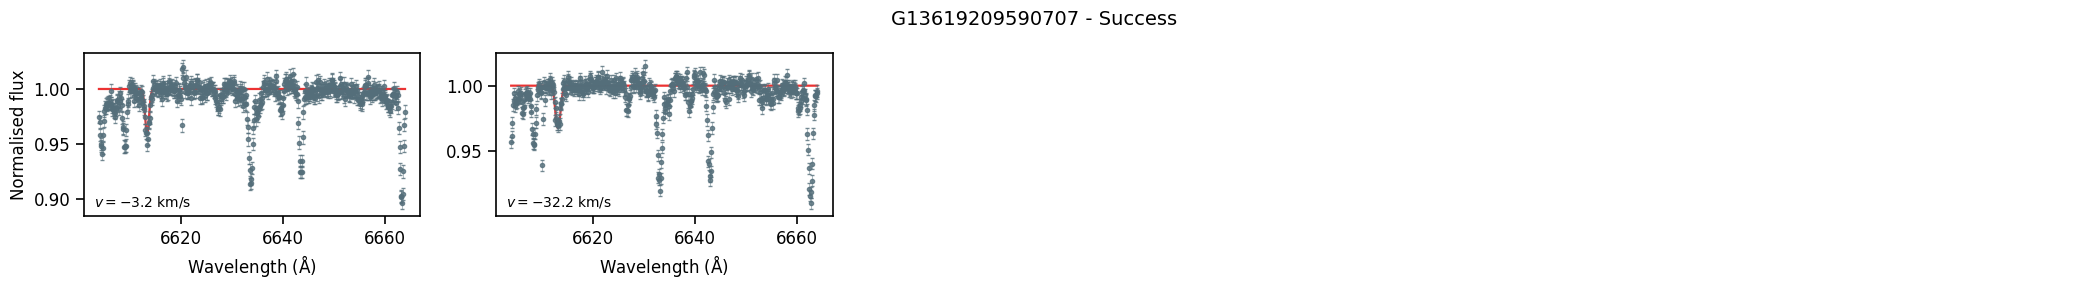

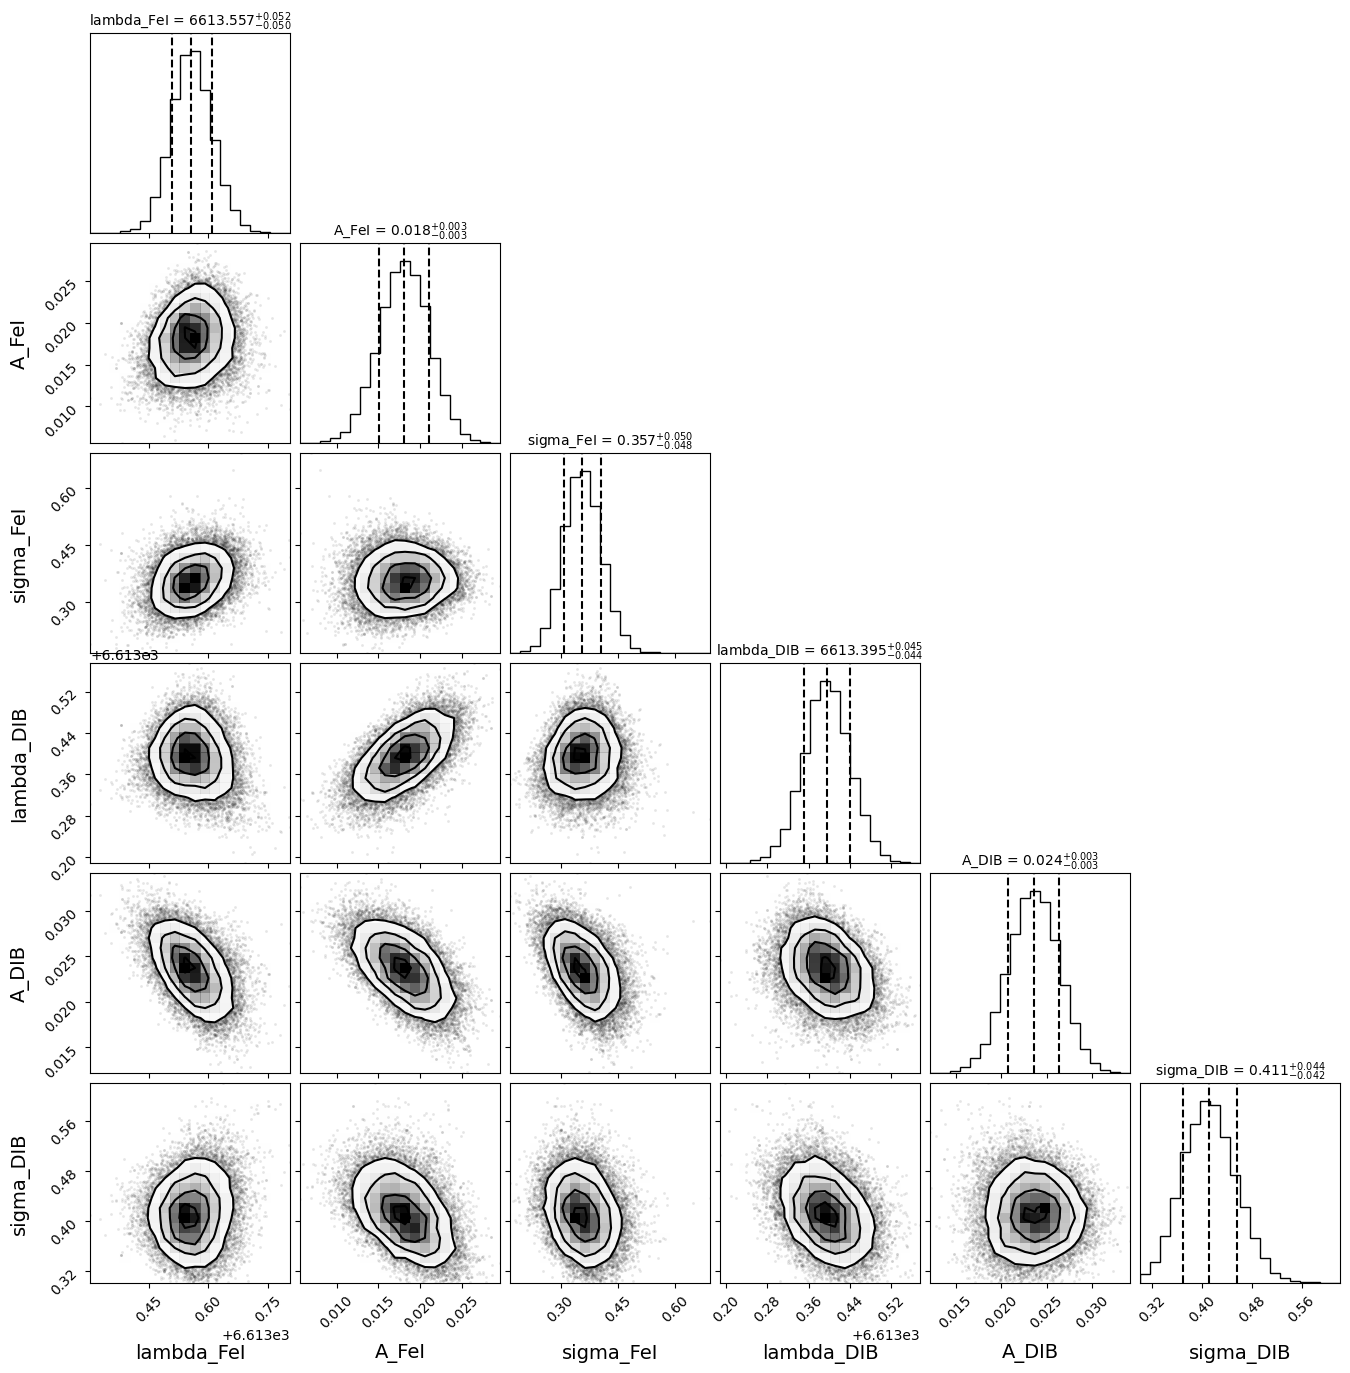

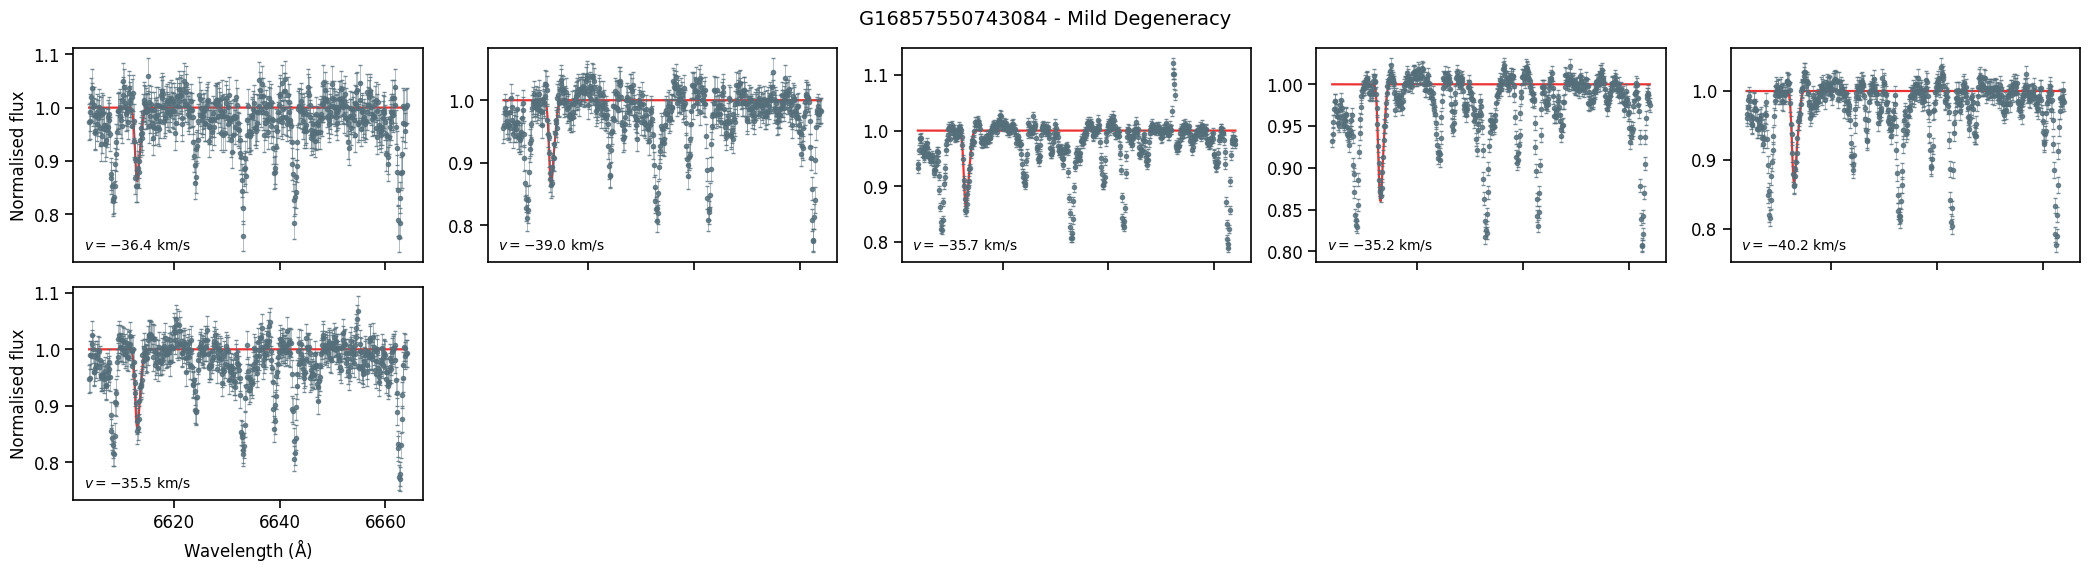

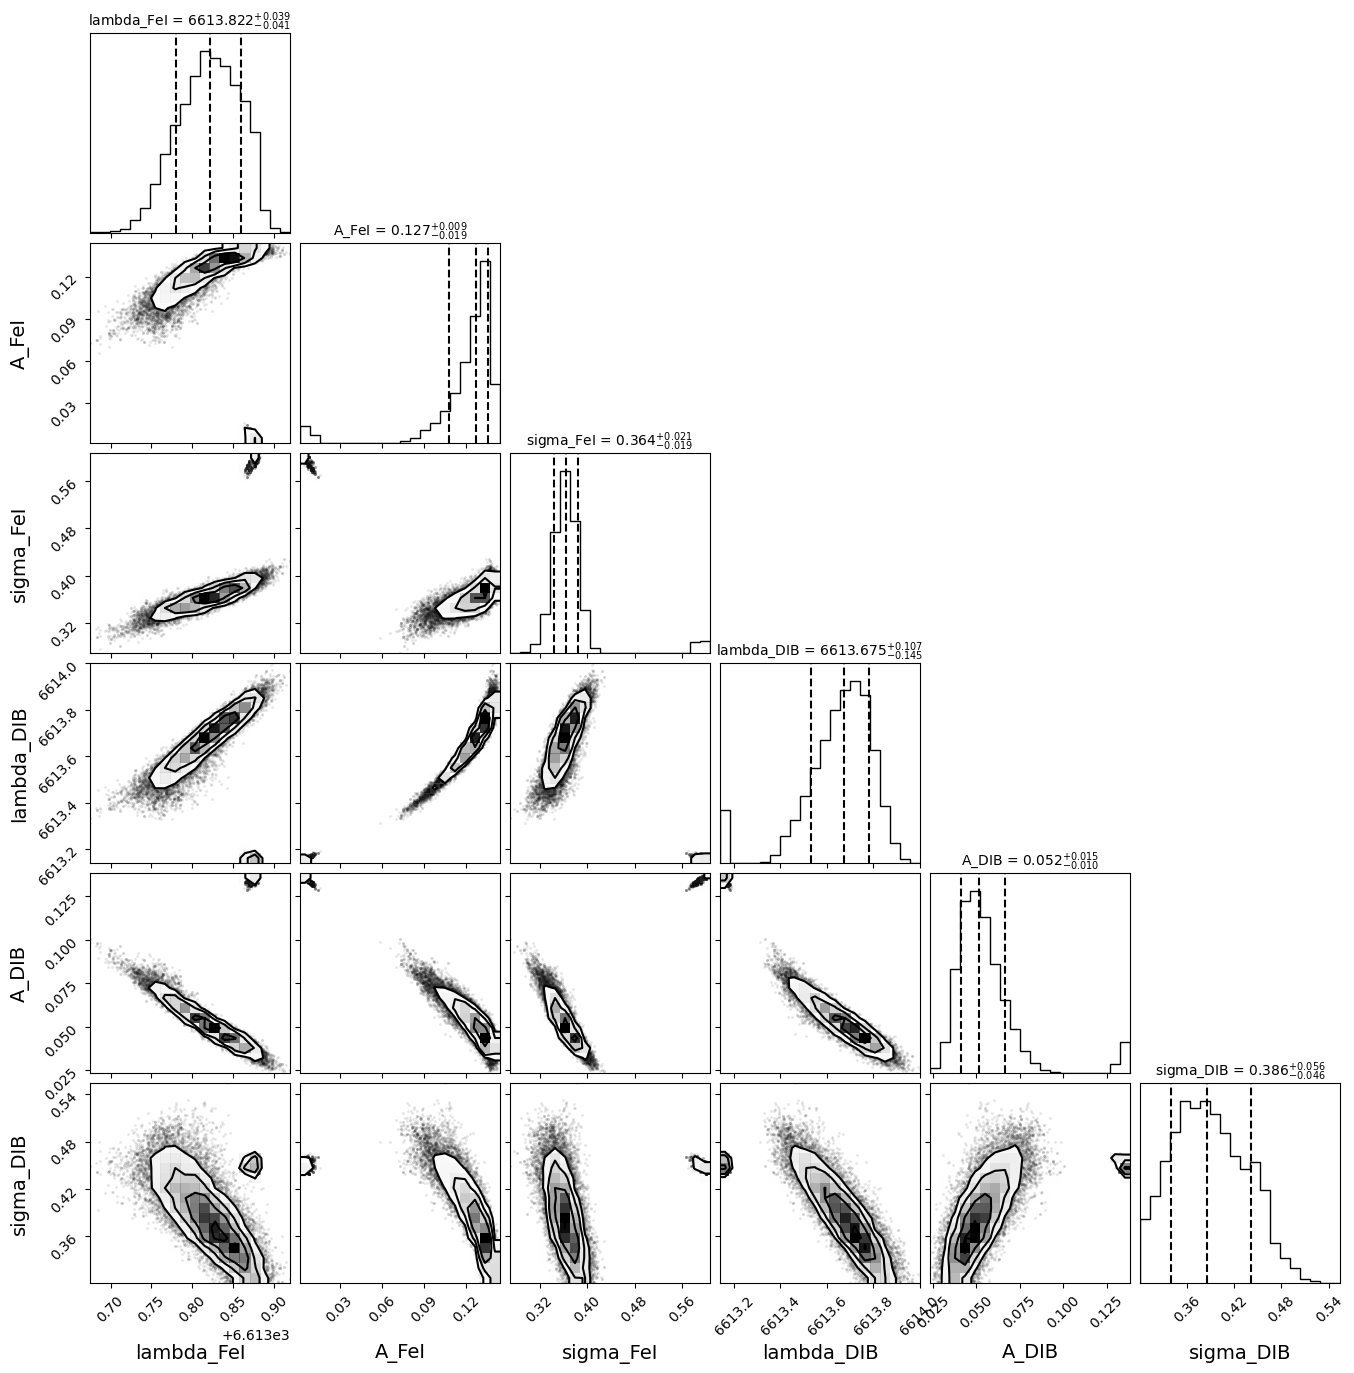

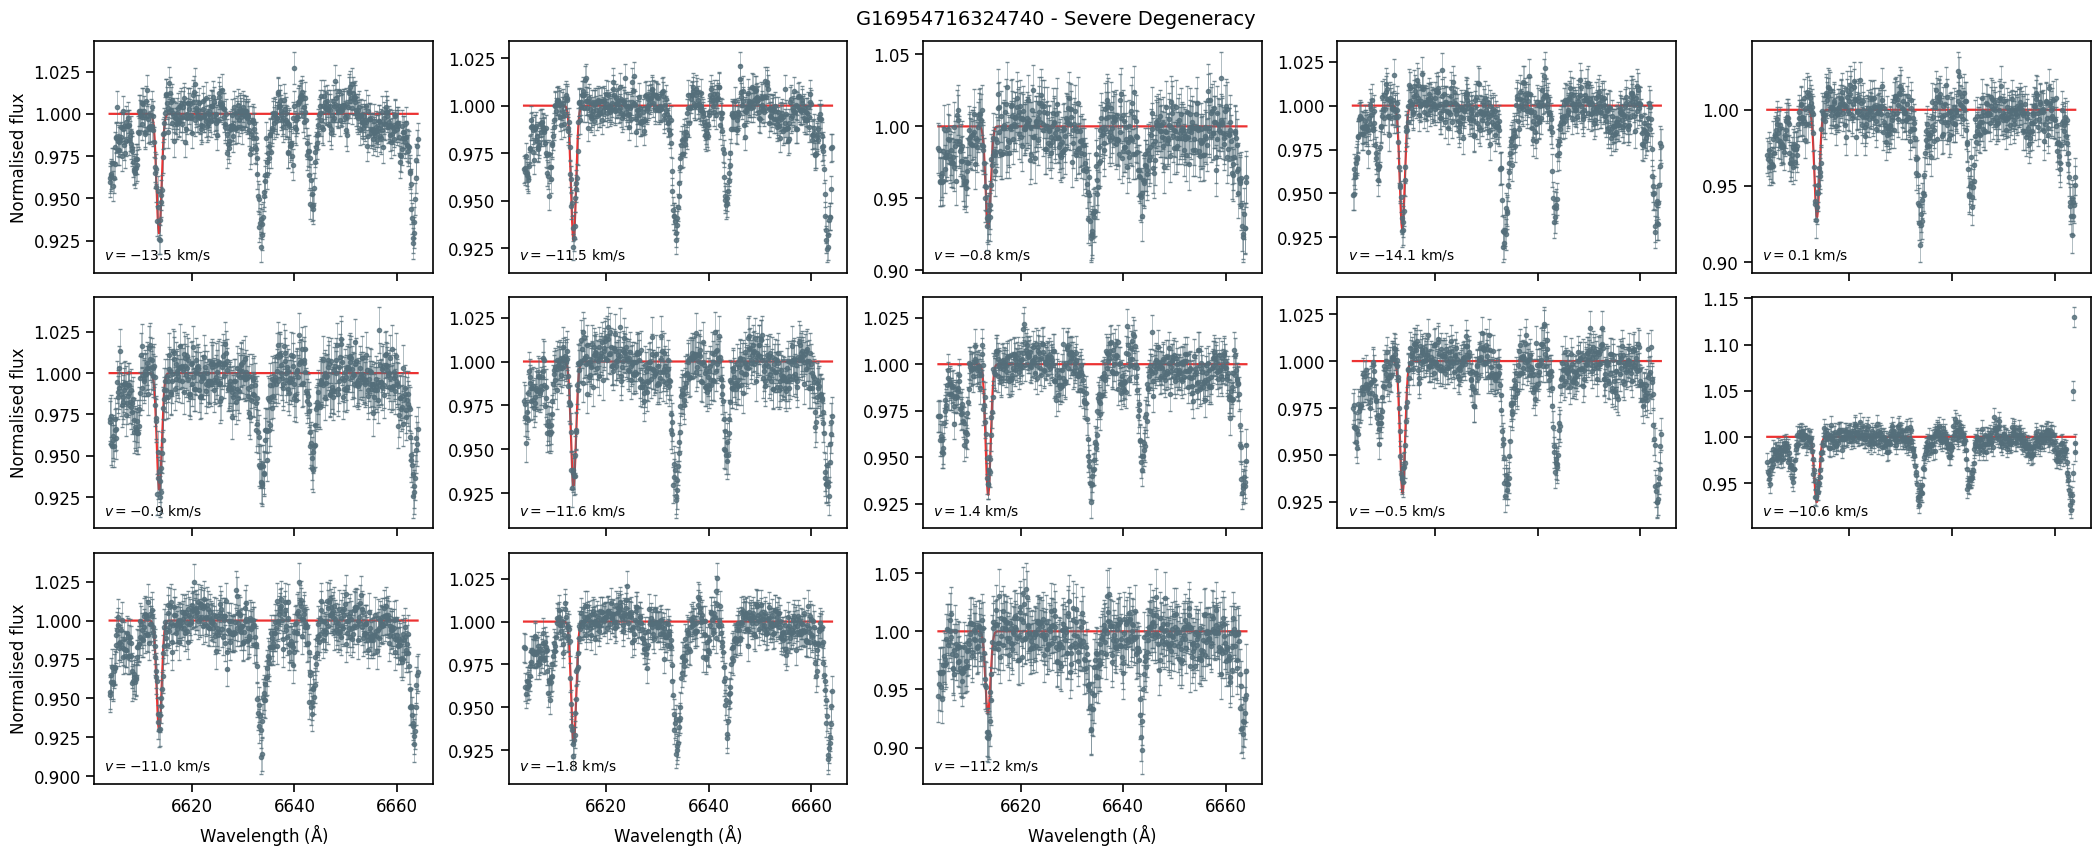

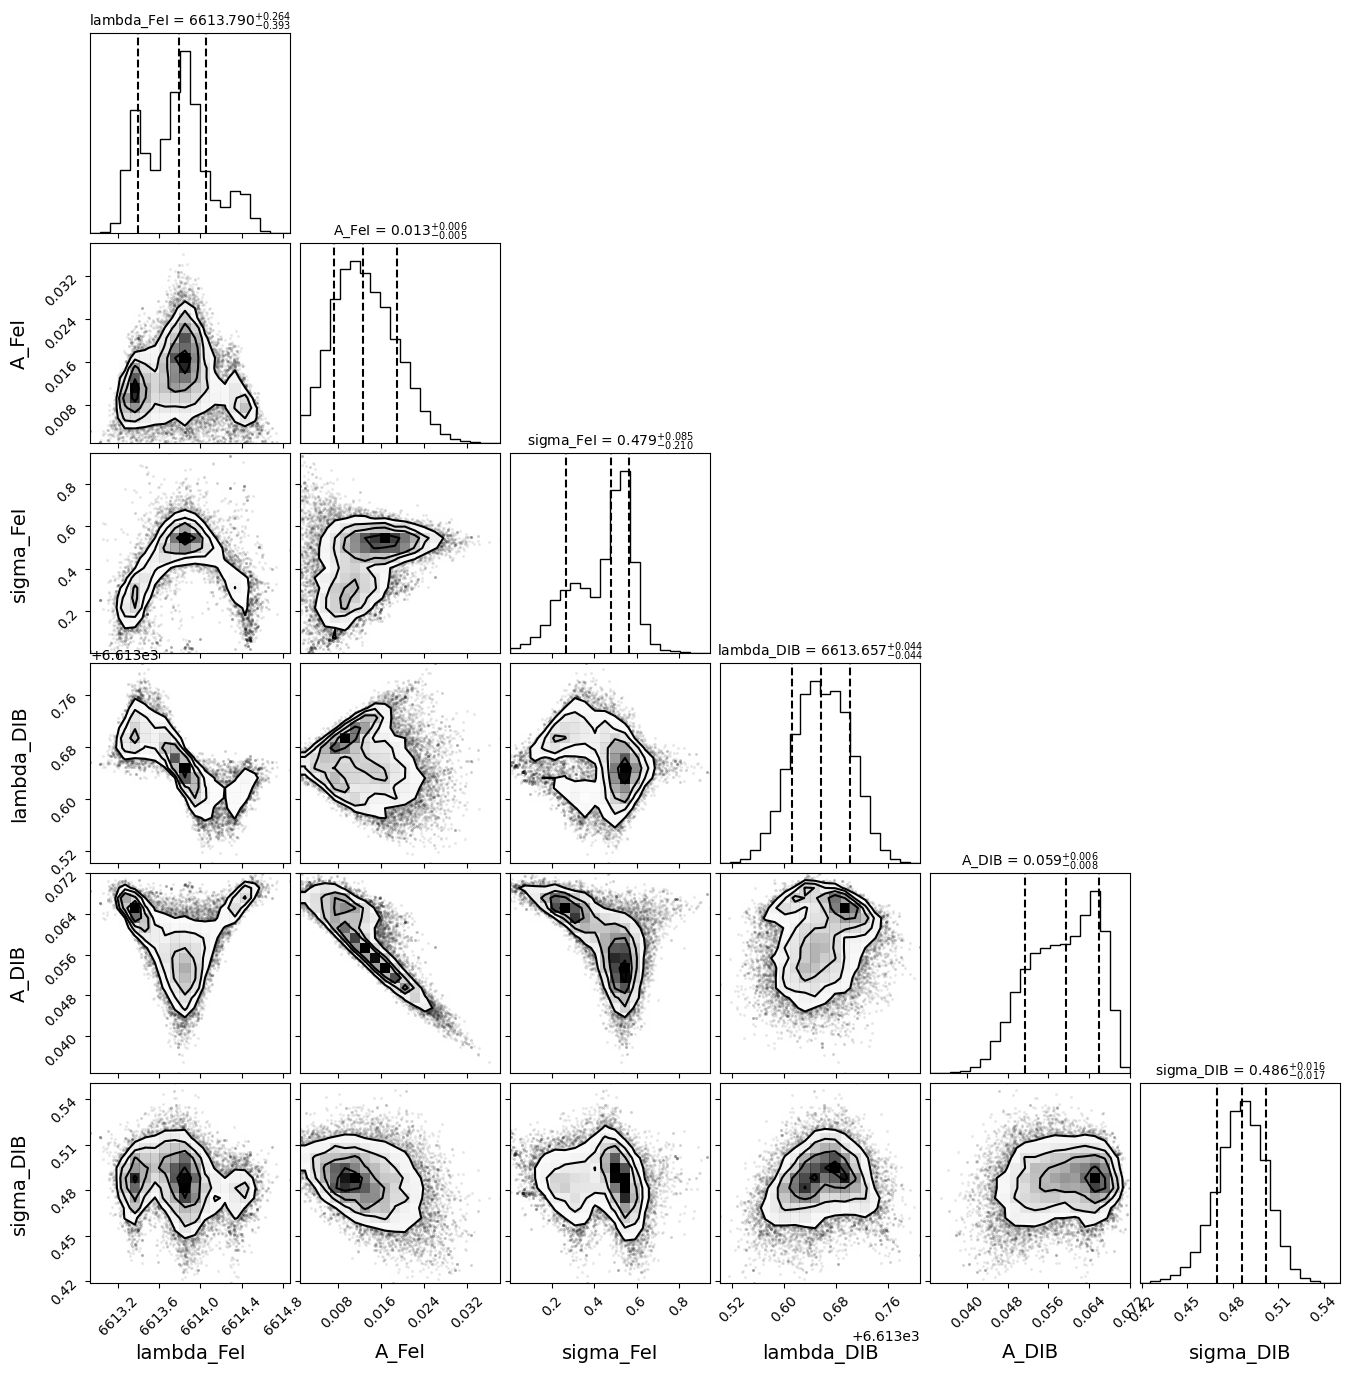

In [5]:
for uid, (d, res) in runs.items():
    plotting.plot_all_epochs(d['wave'], d['flux'], d['flux_err'], d['rvs'], model, res.pfit,
                             ncols=5, title=f'{uid} - {res.label}',
                             out=str(FIG / f'nb05_{uid}_epochs.png'))
    plt.show()
    plotting.plot_corner(res.samples, model.param_names,
                         out=str(FIG / f'nb05_{uid}_corner.png'))
    plt.show()

## 5. Comparison

In [6]:
print(f'{"target":>18} {"label":>18} {"tau":>6} {"RV span":>9} {"med SNR":>8} '
      f'{"lambda_DIB":>11} {"A_DIB":>8} {"sigma_DIB":>10}')
for uid, (d, res) in runs.items():
    q = res.pfit[3:]
    print(f'{uid:>18} {res.label:>18} {np.max(res.tau):6.0f} {np.ptp(d["rvs"]):8.1f} '
          f'{np.median(d["snrs"]):8.1f} {q[0]:11.3f} {q[1]:8.4f} {q[2]:10.3f}')

            target              label    tau   RV span  med SNR  lambda_DIB    A_DIB  sigma_DIB
   G13619209590707            Success     68     29.0    450.8    6613.394   0.0236      0.412
   G16857550743084    Mild Degeneracy    167      5.0    161.8    6613.682   0.0509      0.384
   G16954716324740  Severe Degeneracy    301     15.5    256.2    6613.654   0.0593      0.486


The pattern is the one discussed in the paper: the `Success` target has a large RV span and a high
SNR, so the sampler converges quickly; when the RV span shrinks (or the two components become
similar in width) the posterior becomes degenerate and $\tau$ grows, which is reported by the
label instead of being hidden in the error bars.

## What to take away

* the same six-parameter model works on real data - no target-specific tuning is needed for the
  fiducial DIB;
* $\tau$ is a cheap, model-independent warning: it grows when the fit becomes degenerate;
* for spectra that look suspicious, first check the RV span, the SNR and the sampling, then trust
  the label. If a case cannot be modelled explicitly at all, the label is the last safeguard.